In [47]:

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import time
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

data = load_diabetes(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5}
(1784.0411541773951, np.float64(42.237911337770896), 35.65503435433163, 0.7063982394890709)
Training Time: 1.7828114032745361
Training: MSE=1784.041154, RMSE=42.237911, MAE=35.655034, R²=0.706398
Test: MSE=2821.621973, RMSE=53.118942, MAE=43.463792, R²=0.467433


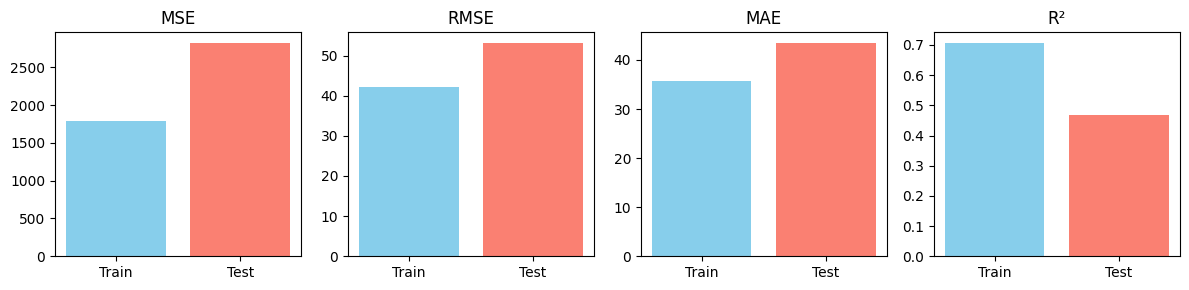

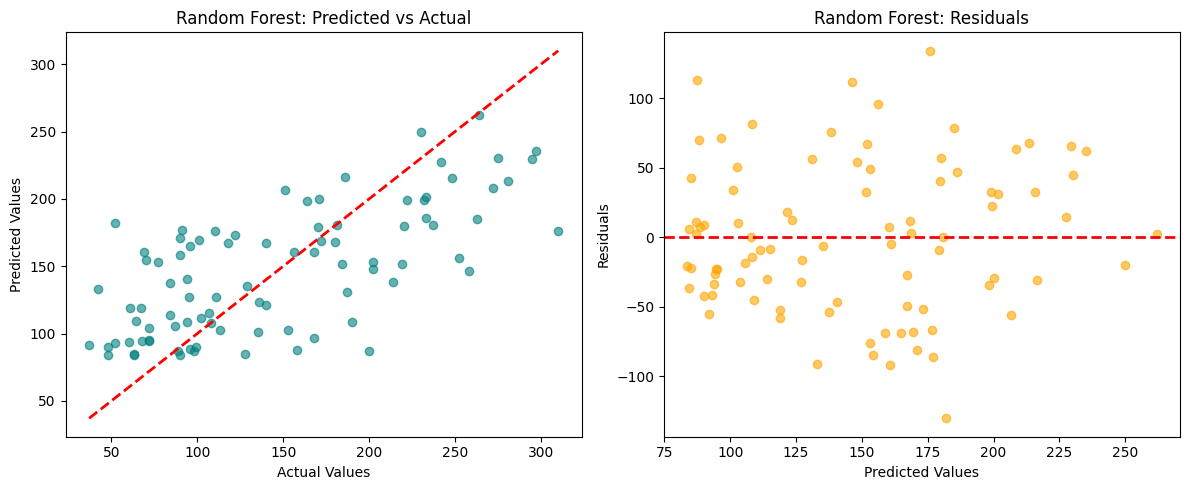


Feature importances:
  feature  importance
2     bmi    0.286563
8      s5    0.236198
3      bp    0.119521
9      s6    0.080279
6      s3    0.078100
7      s4    0.071464
5      s2    0.044472
4      s1    0.042805
0     age    0.034575
1     sex    0.006023


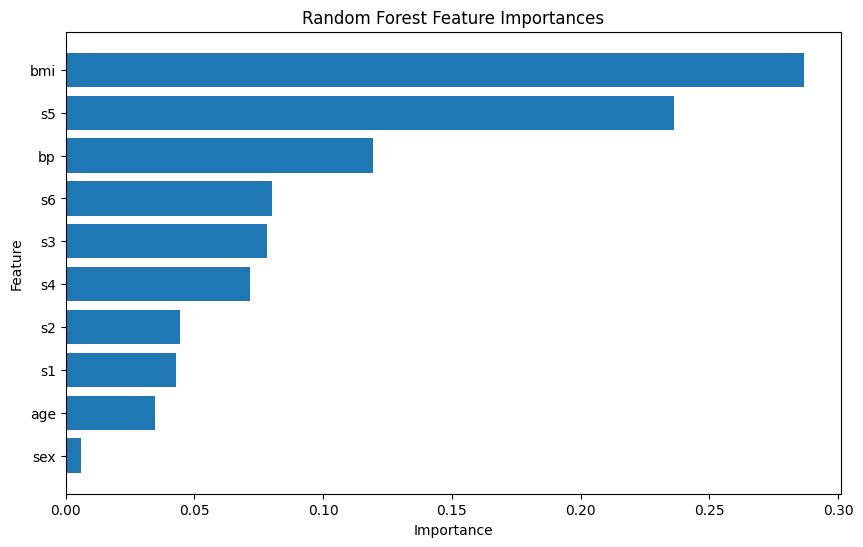

In [59]:
from sklearn.model_selection import RandomizedSearchCV
rf_model = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None]   
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=10,             # only 10 random combos
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)


start_time = time.time()

rf_search.fit(X_train, y_train)
training_time = time.time() - start_time
best_rf = rf_search.best_estimator_
print("Best hyperparameters:", rf_search.best_params_)
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

def regression_scores(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

train_metrics = regression_scores(y_train, y_train_pred)
test_metrics = regression_scores(y_test, y_test_pred)
print(train_metrics)
print(f"Training Time: {training_time}")
print("Training: MSE={:.6f}, RMSE={:.6f}, MAE={:.6f}, R²={:.6f}".format(*train_metrics))
print("Test: MSE={:.6f}, RMSE={:.6f}, MAE={:.6f}, R²={:.6f}".format(*test_metrics))

metrics_names = ['MSE', 'RMSE', 'MAE', 'R²']
train_values = train_metrics
test_values  = test_metrics
x = np.arange(2)  # Train vs Test

fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i, metric in enumerate(metrics_names):
    axes[i].bar(x, [train_values[i], test_values[i]], color=['skyblue','salmon'])
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Train','Test'])
    axes[i].set_title(metric)

plt.tight_layout()
plt.show()

# Scatter plots for Predictions vs Actual and Residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Predicted vs Actual
axes[0].scatter(y_test, y_test_pred, color='teal', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Random Forest: Predicted vs Actual")

# 2. Residuals plot
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, color='orange', alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Random Forest: Residuals")

plt.tight_layout()
plt.show()


importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nFeature importances:")
print(feature_importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.show()

Tuned
Training Time: 1.7735941410064697
Training: MSE=1784.041154, RMSE=42.237911, MAE=35.655034, R²=0.706398
Test: MSE=2821.621973, RMSE=53.118942, MAE=43.463792, R²=0.467433

Default
Training Time:
Training: MSE=460.493093, RMSE=21.459103, MAE=17.406544, R²=0.924216
Test: MSE=2952.010589, RMSE=54.332408, MAE=44.053034, R²=0.442823

,Model,Training Time (s),Train MSE,Train RMSE,Train MAE,Train R²,Test MSE,Test RMSE,Test MAE,Test R²
0,Default,0.1579,460.493093,21.459103,17.406544,0.924216,2952.010589,54.332408,44.053034,0.442823
1,Tuned,1.7736,1784.041154,42.237911,35.655034,0.706398,2821.621973,53.118942,43.463792,0.467433


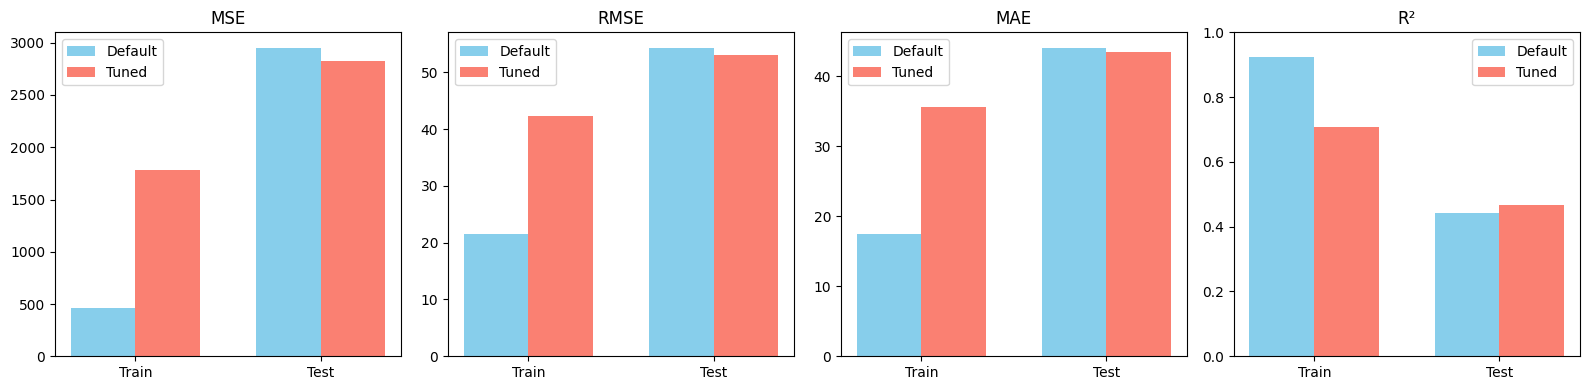

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the model metrics
data = {
    "Model": ["Default", "Tuned"],
    "Training Time (s)": [0.1579, 1.7736],
    "Train MSE": [460.493093, 1784.041154],
    "Train RMSE": [21.459103, 42.237911],
    "Train MAE": [17.406544, 35.655034],
    "Train R²": [0.924216, 0.706398],
    "Test MSE": [2952.010589, 2821.621973],
    "Test RMSE": [54.332408, 53.118942],
    "Test MAE": [44.053034, 43.463792],
    "Test R²": [0.442823, 0.467433]
}

# Create DataFrame
df_metrics = pd.DataFrame(data)
display(df_metrics)

metrics_names = ['MSE', 'RMSE', 'MAE', 'R²']

# Default model metrics
default_train = [460.493093, 21.459103, 17.406544, 0.924216]
default_test  = [2952.010589, 54.332408, 44.053034, 0.442823]

# Tuned model metrics
tuned_train = [1784.041154, 42.237911, 35.655034, 0.706398]
tuned_test  = [2821.621973, 53.118942, 43.463792, 0.467433]

x = np.arange(2)  # Train vs Test
width = 0.35     # Width of the bars

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, metric in enumerate(metrics_names):
    axes[i].bar(x - width/2, [default_train[i], default_test[i]], width, label='Default', color='skyblue')
    axes[i].bar(x + width/2, [tuned_train[i], tuned_test[i]], width, label='Tuned', color='salmon')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Train','Test'])
    axes[i].set_title(metric)
    if metric == 'R²':  # R² is 0–1 scale
        axes[i].set_ylim(0,1)
    axes[i].legend()

plt.tight_layout()
plt.show()
